In [7]:
# 1. Cargar la librería necesaria
if (!require("pheatmap")) install.packages("pheatmap")
library(pheatmap)

# 1. Cargar librería para gráficos
if (!require("ggplot2")) install.packages("ggplot2")
library(ggplot2)

Cargando paquete requerido: ggplot2



In [5]:
# 1. Leer el archivo intentando detectar el separador (coma o tabulación)
# Probamos primero con tabulación que es el estándar de GEO
data <- read.delim("GSE196917_RawCounts.csv", sep="\t", check.names=FALSE)

# Si se leyó mal (solo una columna), re-intentamos con coma
if(ncol(data) <= 1) {
  data <- read.csv("GSE196917_RawCounts.csv", check.names=FALSE)
}

[1] "Usando la columna: Name"


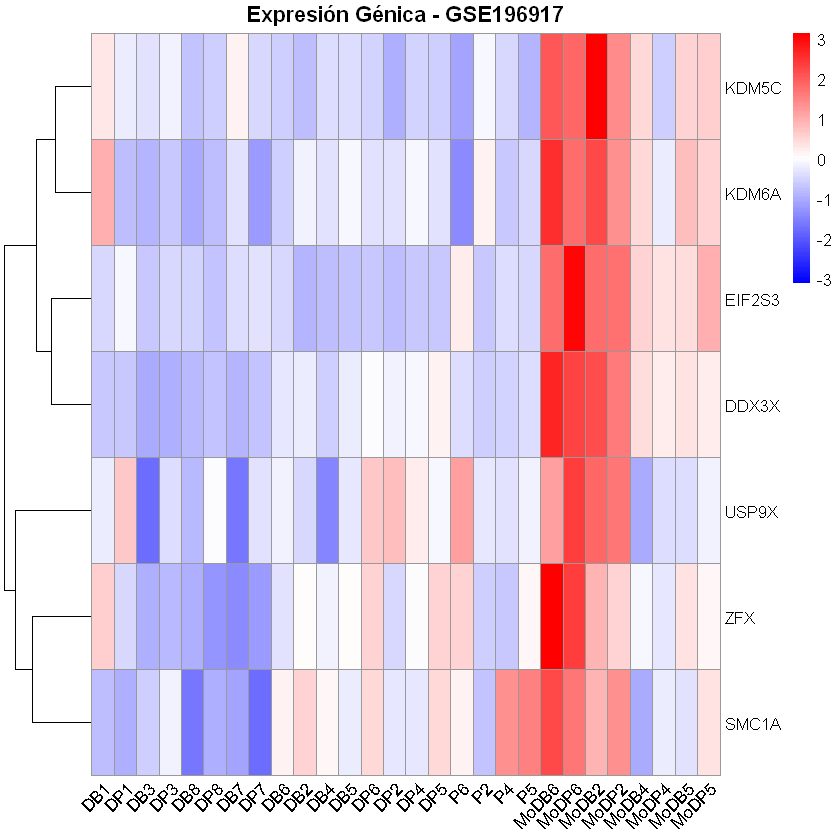

In [6]:
# 2. Corregir nombres de genes (KDM6A es el correcto)
genes_interes <- c("KDM6A", "KDM5C", "EIF2S3", "DDX3X", "SMC1A", "USP9X", "ZFX")

# 3. Buscar en qué columna están los genes
# Buscamos la columna que contenga "KDM5C" (que es único)
col_index <- which(apply(data, 2, function(x) any(x %in% genes_interes)))

if(length(col_index) == 0) {
  stop("No se encontraron los genes. Corré 'head(data)' y fijate cómo se llama la columna de los genes.")
}

nombre_columna_genes <- colnames(data)[col_index[1]]
print(paste("Usando la columna:", nombre_columna_genes))

# 4. Filtrar
df_filtered <- data[data[[nombre_columna_genes]] %in% genes_interes, ]

# 5. Si después de filtrar tenemos datos, graficamos
if (nrow(df_filtered) > 0) {
    
    # Seteamos rownames y quitamos duplicados si los hay
    rownames(df_filtered) <- make.unique(as.character(df_filtered[[nombre_columna_genes]]))
    
    # Definimos tus muestras
    muestras <- c("DB1", "DP1", "DB3", "DP3", "DB8", "DP8", "DB7", "DP7", "DB6", "DB2", 
                  "DB4", "DB5", "DP6", "DP2", "DP4", "DP5", "P6", "P2", "P4", "P5", 
                  "MoDB6", "MoDP6", "MoDB2", "MoDP2", "MoDB4", "MoDP4", "MoDB5", "MoDP5")
    
    # Solo nos quedamos con las muestras que realmente existan en el archivo
    muestras_presentes <- muestras[muestras %in% colnames(df_filtered)]
    matriz_plot <- as.matrix(df_filtered[, muestras_presentes])
    
    # Convertir a numérico (por si se leyó como texto)
    class(matriz_plot) <- "numeric"
    
    # 6. El Heatmap
    pheatmap(matriz_plot, 
             main = "Expresión Génica - GSE196917",
             scale = "row", 
             cluster_cols = FALSE, 
             cluster_rows = TRUE,
             color = colorRampPalette(c("blue", "white", "red"))(100),
             fontsize_row = 10,
             angle_col = 45)
} else {
    print("No se encontraron coincidencias para los genes buscados.")
}

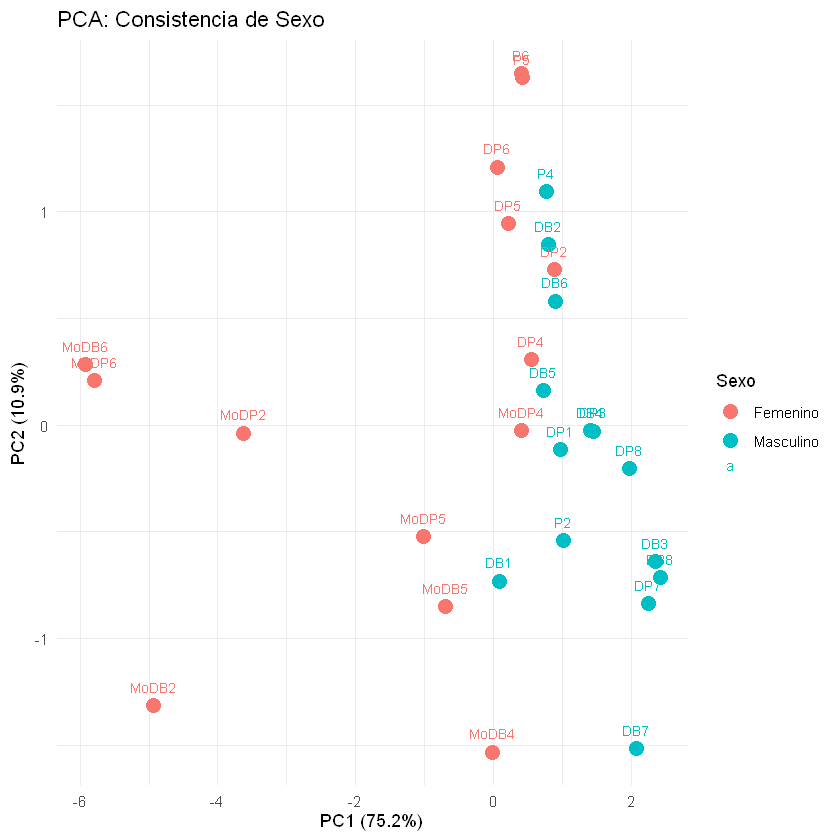

In [18]:
# 1. Ejecutar el PCA
# Usamos scale. = TRUE para que todos los genes tengan el mismo peso
pca_res <- prcomp(t(matriz_plot), scale. = TRUE)

# 2. CALCULO CORRECTO DE VARIANZA
varianzas <- pca_res$sdev^2
porcentajes <- (varianzas / sum(varianzas)) * 100

# 3. Extraer PC1 y PC2
pc1_var <- round(porcentajes[1], 1)
pc2_var <- round(porcentajes[2], 1)

# 4. Graficar (verificando que no de 400!)
library(ggplot2)
df_pca <- as.data.frame(pca_res$x)
df_pca$Sample <- rownames(df_pca)

# Clasificación rápida por expresión total para el color
df_pca$Sexo <- ifelse(rowSums(t(matriz_plot)) > median(rowSums(t(matriz_plot))), "Femenino", "Masculino")

ggplot(df_pca, aes(x = PC1, y = PC2, color = Sexo, label = Sample)) +
  geom_point(size = 4) +
  geom_text(vjust = -1.2, size = 3) +
  labs(title = "PCA: Consistencia de Sexo",
       x = paste0("PC1 (", pc1_var, "%)"), 
       y = paste0("PC2 (", pc2_var, "%)")) +
  theme_minimal()